In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Descargando...
Descomprimiendo...
Mostrando imágenes:


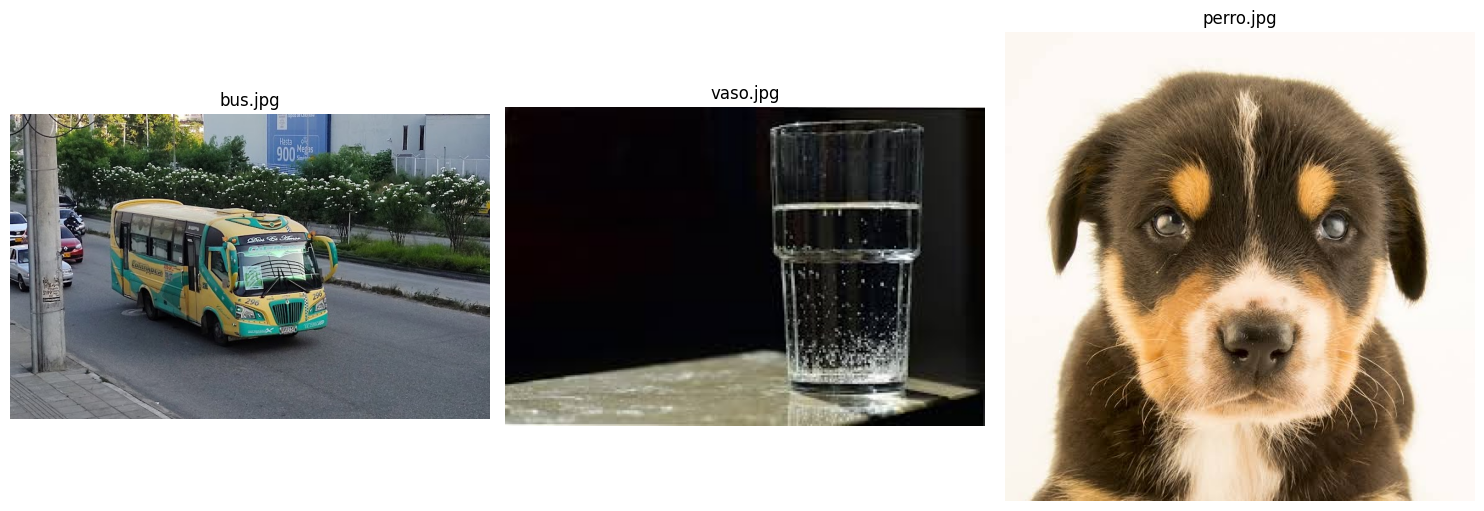

In [2]:
import urllib.request
import zipfile
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Opcional: Cambiar esta ruta si quieres guardarlo directamente en tu Drive
# Por ejemplo: extract_path = '/content/drive/MyDrive/imagenesvgg16'
base_path = '/content' 

url = "https://github.com/adiacla/bigdata/raw/refs/heads/master/imagenesvgg16.zip"
zip_path = os.path.join(base_path, "imagenesvgg16.zip")
extract_path = os.path.join(base_path, "imagenesvgg16")

# 1. Descargar el archivo .zip
print("Descargando...")
urllib.request.urlretrieve(url, zip_path)

# 2. Descomprimir el archivo
print("Descomprimiendo...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3. Leer y Mostrar las imágenes
print("Mostrando imágenes:")
# Buscamos todos los archivos .jpg en la carpeta
imagenes = [f for f in os.listdir(extract_path) if f.endswith('.jpg') or f.endswith('.png')]

# Configuramos la visualización (por ejemplo, 1 fila con las columnas que sean necesarias)
plt.figure(figsize=(15, 5))

for i, img_name in enumerate(imagenes):
    img_path = os.path.join(extract_path, img_name)
    img = mpimg.imread(img_path)
    
    # Creamos un subplot para cada imagen
    plt.subplot(1, len(imagenes), i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [3]:
import numpy as np

# Importar el modelo ResNet50, además del preprocesamiento y decodificador de predicciones específicos para ResNet
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# Importar la biblioteca de procesamiento de imágenes para cargar y preparar las imágenes
from tensorflow.keras.preprocessing import image


In [4]:
# Cargar el modelo base preentrenado con ImageNet y con la capa superior (top) incluida.
modelo_base = ResNet50(include_top=True, weights='imagenet')

# (Opcional) Puedes ver la arquitectura completa del modelo ejecutando:
# modelo_base.summary()


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
modelo_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [6]:
# 1. Arreglo llamado 'nuevas_imagenes' con las rutas del perro, bus y vaso
nuevas_imagenes = [
    '/content/imagenesvgg16/perro.jpg',
    '/content/imagenesvgg16/bus.jpg',
    '/content/imagenesvgg16/vaso.jpg'
]

# Lista vacía donde iremos agregando el resultado
lista_imagenes_procesadas = []

for path in nuevas_imagenes:
    # 2. Cargar imagen y redimensionar a 224x224
    img = image.load_img(path, target_size=(224, 224))
    
    # 3. Convertir imagen a arreglo de un arreglo numérico (numpy)
    x = image.img_to_array(img)
    
    # 4. Expandir la dimensionalidad (Agrega la dimensión del lote/batch)
    # Pasa de tener una forma (224, 224, 3) a tener forma (1, 224, 224, 3)
    x = np.expand_dims(x, axis=0)
    
    # 5. Hacer el preprocess_input para que tenga el formato exacto que pide ResNet
    x = preprocess_input(x)
    
    # 6. Agregarlas a nuestra lista temporal
    lista_imagenes_procesadas.append(x)

# 7. Unir todas las imágenes individuales en un único "lote" de imágenes continuo.
# El tamaño final quedará como (3, 224, 224, 3), ya que son 3 imágenes.
lote_imagenes = np.vstack(lista_imagenes_procesadas)

print("El tamaño del arreglo final de imágenes es:", lote_imagenes.shape)


El tamaño del arreglo final de imágenes es: (3, 224, 224, 3)


In [7]:
lista_imagenes_procesadas

[array([[[[137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          ...,
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ]],
 
         [[137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          ...,
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ]],
 
         [[137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          ...,
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ]],
 
         ...,
 
         [[133.061  , 129.22101, 126.32   ],
          [133.061  , 129.22101, 126.32   ],
          [133.061  , 129.2210

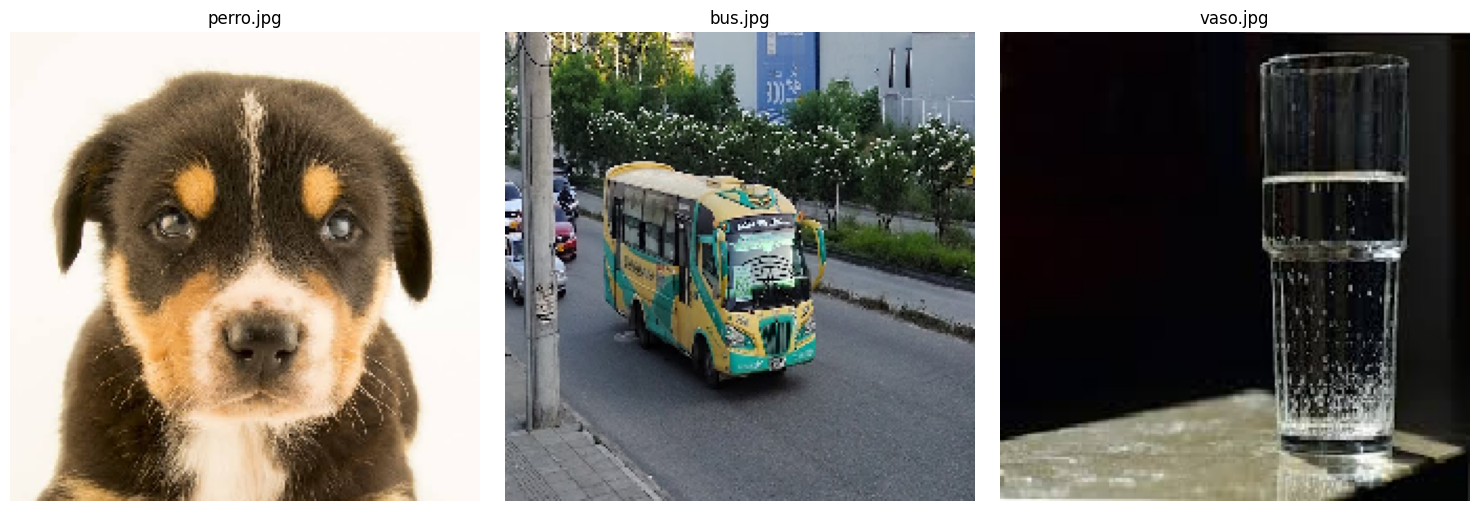

In [8]:
import matplotlib.pyplot as plt

# Configuramos el tamaño del marco general donde se verán las imágenes
plt.figure(figsize=(15, 5))

for i, path in enumerate(nuevas_imagenes):
    # Volvemos a cargar la imagen con Keras (esto nos da la imagen original sin colores alterados)
    img_para_mostrar = image.load_img(path, target_size=(224, 224))
    
    # Creamos un "Sub-gráfico" (1 fila total, cantidad de imágenes, posición actual)
    plt.subplot(1, len(nuevas_imagenes), i + 1)
    
    # Mostramos la imagen
    plt.imshow(img_para_mostrar)
    
    # Ponemos el nombre del archivo como título (ej. "perro.jpg")
    nombre_archivo = path.split('/')[-1]
    plt.title(nombre_archivo)
    
    # Apagamos los ejes (para no ver los números de los pixeles a los lados)
    plt.axis('off')

# Esto asegura que los gráficos no se superpongan entre sí
plt.tight_layout()
plt.show()


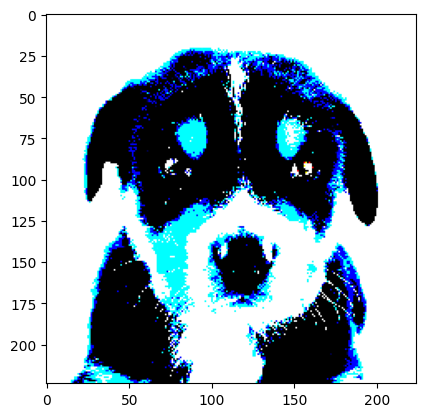

In [9]:
# Solo para que veas el tensor alterado por el preprocesamiento
plt.imshow(lote_imagenes[0])
# (Esto podría soltarte una advertencia en Matplotlib porque los números ya no están en un formato estándar de imagen)


In [10]:
# 1. Hacer la predicción: 
# Le pasamos el "lote_imagenes" que contiene nuestras 3 imágenes juntas preprocesadas
print("Realizando predicciones...")
predicciones = modelo_base.predict(lote_imagenes)

# 2. Decodificar esos resultados:
# La función "decode_predictions" traduce el arreglo matemático a nombres de ImageNet en texto.
# Con top=3 le decimos que solo queremos las 3 opciones con mayor probabilidad por imagen.
resultados_decodificados = decode_predictions(predicciones, top=3)

# 3. Mostrar los resultados de forma elegante
for i, path in enumerate(nuevas_imagenes):
    nombre_archivo = path.split('/')[-1]
    print(f"\n--- Top 3 Predicciones para {nombre_archivo} ---")
    
    # Iteramos sobre las 3 predicciones de la imagen actual (índice i)
    # decode_predictions devuelve una lista donde cada elemento es una tupla: (Clase_ID, Nombre_Item, Probabilidad)
    for prediccion in resultados_decodificados[i]:
        id_clase, nombre, probabilidad = prediccion
        # Multiplicamos la probabilidad por 100 para que se vea como porcentaje (%)
        print(f" -> {nombre}: {probabilidad * 100:.2f}%")


Realizando predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Top 3 Predicciones para perro.jpg ---
 -> EntleBucher: 64.31%
 -> Appenzeller: 27.86%
 -> Greater_Swiss_Mountain_dog: 6.96%

--- Top 3 Predicciones para bus.jpg ---
 -> trolleybus: 43.80%
 -> minibus: 37.91%
 -> garbage_truck: 9.72%

--- Top 3 Predicciones para vaso.jpg ---
 -> beaker: 37.11%
 -> cocktail_shaker: 34.29%
 -> beer_glass: 17.76%


#   Transferlearning para perros y gatos

In [11]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [14]:
import os
import tensorflow as tf

# URL proporcionada
url_dataset = "https://www.kaggle.com/api/v1/datasets/download/birajsth/cats-and-dogs-filtered"

# 1. Descargar y descomprimir con Keras
print("Iniciando descarga y descompresión...")
ruta_zip = tf.keras.utils.get_file(
    fname='cats_and_dogs_kaggle.zip',   # Nombre temporal para el zip
    origin=url_dataset,                 # Link de descarga
    extract=True,                       # ¡Descomprimir automáticamente!
    cache_dir='/dog_cat'        # Carpeta base donde guardar. Keras creará internamente otra llamada 'datasets'
)

# Obtenemos la ruta final exacta donde quedó descomprimido
carpeta_extraccion = os.path.dirname(ruta_zip)

# 2. Guardar los nombres de todos los archivos en un arreglo (lista)
lista_nombres_archivos = []

# os.walk es como un escáner que revisa todas las carpetas y subcarpetas por dentro
for ruta_actual, directorios, archivos in os.walk(carpeta_extraccion):
    for archivo in archivos:
        # Filtramos para asegurarnos de guardar solo las imágenes (ignorando cosas como el .zip o archivos ocultos de sistema)
        if archivo.lower().endswith(('.jpg', '.png', '.jpeg')):
            ruta_completa = os.path.join(ruta_actual, archivo)
            # Guardamos la ruta en nuestra variable
            lista_nombres_archivos.append(ruta_completa)


# 3. Comprobación para que veas que todo funcionó
print("-" * 50)
print(f"✅ Descarga terminada. Se guardaron {len(lista_nombres_archivos)} nombres de imágenes en la lista.")
print("Aquí están los nombres de los primeros 5 archivos encontrados:\n")

for nombre in lista_nombres_archivos[:5]:
    print(nombre)


Iniciando descarga y descompresión...
--------------------------------------------------
✅ Descarga terminada. Se guardaron 6000 nombres de imágenes en la lista.
Aquí están los nombres de los primeros 5 archivos encontrados:

/tmp/.keras/datasets/cats_and_dogs_kaggle_extracted/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.42.jpg
/tmp/.keras/datasets/cats_and_dogs_kaggle_extracted/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.580.jpg
/tmp/.keras/datasets/cats_and_dogs_kaggle_extracted/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.972.jpg
/tmp/.keras/datasets/cats_and_dogs_kaggle_extracted/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.641.jpg
/tmp/.keras/datasets/cats_and_dogs_kaggle_extracted/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.306.jpg


In [15]:
# Seleccionamos la raíz de la carpeta que traía el zip (normalmente termina llamándose "cats_and_dogs_filtered")
carpeta_dataset = os.path.join(carpeta_extraccion, 'cats_and_dogs_filtered')

# Construimos los directorios apuntando a las carpetas 'train' y 'validation'
ruta_entrenamiento = os.path.join(carpeta_dataset, 'train')
ruta_validacion = os.path.join(carpeta_dataset, 'validation')

# Imprimir en pantalla para validar que las rutas quedaron bien construidas
print("📁 Ruta de archivos de Entrenamiento:", ruta_entrenamiento)
print("📁 Ruta de archivos de Validación:", ruta_validacion)


# -----(Opcional para que lo tengas referenciado)-----
# Si quisieras también definir en código de forma súper estricta 
# dónde están los gatos y los perros dentro de entrenamiento, harías esto:
ruta_cats_train = os.path.join(ruta_entrenamiento, 'cats')
ruta_dogs_train = os.path.join(ruta_entrenamiento, 'dogs')


📁 Ruta de archivos de Entrenamiento: /tmp/.keras/datasets/cats_and_dogs_filtered/train
📁 Ruta de archivos de Validación: /tmp/.keras/datasets/cats_and_dogs_filtered/validation


In [19]:
import os
import tensorflow as tf

# Usamos un servidor espejo (mirror) educativo activo que contiene el mismo dataset original
URL_MIRROR = 'https://storage.googleapis.com/ztm_tf_course/food_vision/cats_and_dogs_filtered.zip'

print("Descargando imágenes desde el servidor alternativo...")

ruta_zip = tf.keras.utils.get_file(
    fname='cats_and_dogs_filtrado.zip', 
    origin=URL_MIRROR, 
    extract=True
)

# 2. Construimos las rutas
carpeta_base = os.path.join(os.path.dirname(ruta_zip), 'cats_and_dogs_filtered')
ruta_entrenamiento = os.path.join(carpeta_base, 'train')
ruta_validacion = os.path.join(carpeta_base, 'validation')

print("Rutas configuradas con éxito en:", carpeta_base)

# 3. Cargamos los datasets
batch_size = 32
img_size = (224, 224)

print("\nCargando el set de entrenamiento...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_entrenamiento,
    shuffle=True,          
    batch_size=batch_size, 
    image_size=img_size    
)

print("Cargando el set de validación...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_validacion,
    shuffle=True,          
    batch_size=batch_size, 
    image_size=img_size    
)


Descargando imágenes desde el servidor alternativo...


Exception: URL fetch failure on https://storage.googleapis.com/ztm_tf_course/food_vision/cats_and_dogs_filtered.zip: 403 -- Forbidden